<a href="https://colab.research.google.com/github/Julianmoralez/Retos-Colab/blob/Retos-Colab/M%C3%A9todos_de_Clusterizaci%C3%B3n_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción al Clustering K-Means

El **Clustering K-Means** es un algoritmo de aprendizaje no supervisado que se utiliza para agrupar conjuntos de datos en 'k' clusters (grupos) distintos. Su objetivo es particionar 'n' observaciones en 'k' clusters, donde cada observación pertenece al cluster cuyo centroide (media) le es más cercano.

### ¿Cómo funciona?

1.  **Inicialización**: Se eligen aleatoriamente `k` puntos como centroides iniciales (o se usan métodos más sofisticados).
2.  **Asignación**: Cada punto de datos se asigna al centroide más cercano, formando `k` clusters.
3.  **Actualización**: Los centroides se recalculan como la media de todos los puntos de datos asignados a ese cluster.
4.  **Convergencia**: Los pasos 2 y 3 se repiten hasta que los centroides no cambien significativamente o hasta que se alcance un número máximo de iteraciones. Esto indica que los clusters se han estabilizado.

### Aplicaciones comunes:

*   **Segmentación de clientes**: Agrupar clientes con comportamientos de compra similares.
*   **Compresión de imágenes**: Reducir el número de colores en una imagen.
*   **Detección de anomalías**: Identificar patrones inusuales en los datos.
*   **Agrupación de documentos**: Organizar documentos por temas similares.

Ahora, veamos un ejemplo de cómo aplicar K-Means en Python para agrupar algunos datos sintéticos.

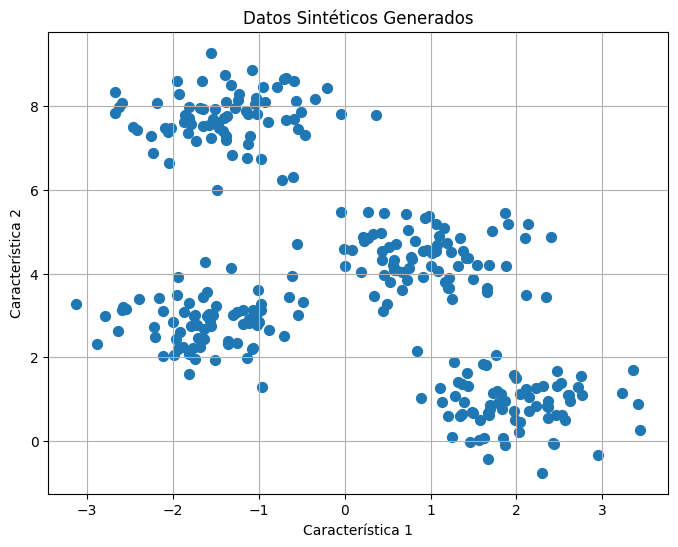

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. Generar datos sintéticos para clustering
# Creamos 3 "blobs" (grupos) de datos para un ejemplo claro.
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Visualizamos los datos generados
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title('Datos Sintéticos Generados')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.grid(True)
plt.show()

Hemos generado 300 puntos de datos que visualmente parecen formar 4 grupos distintos. Ahora aplicaremos el algoritmo K-Means para intentar identificar estos grupos.

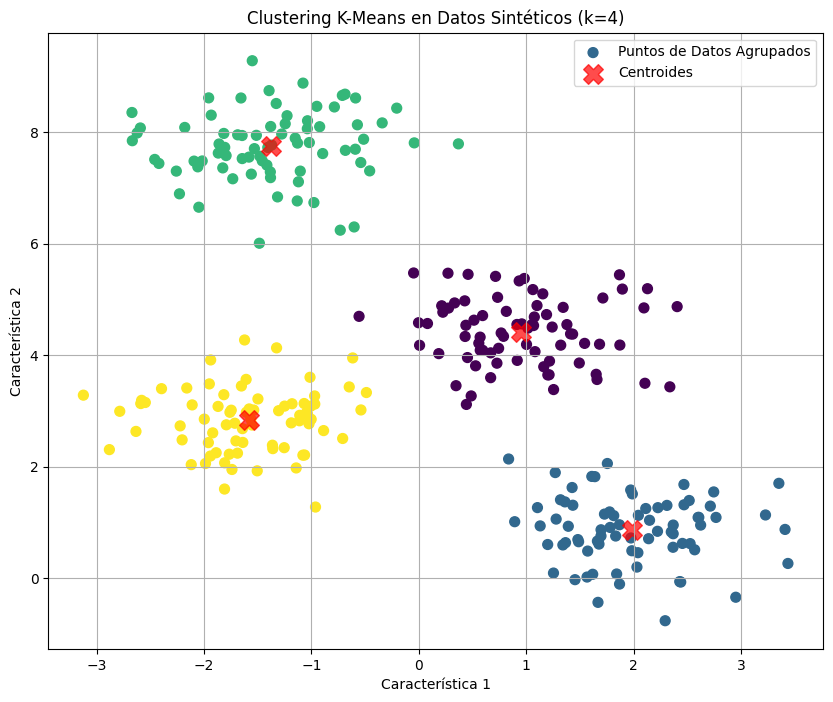

In [ ]:
# 2. Aplicar K-Means
# Instanciamos el modelo K-Means con k=4 (ya que sabemos que hay 4 grupos en los datos generados).
# 'n_init=10' asegura que el algoritmo se ejecute 10 veces con diferentes semillas de centroides iniciales
# y elija el mejor resultado.
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=0)

# Entrenamos el modelo con nuestros datos
kmeans.fit(X)

# Obtenemos las etiquetas de los clusters a los que pertenece cada punto
y_kmeans = kmeans.predict(X)

# Obtenemos las coordenadas de los centroides de los clusters
centers = kmeans.cluster_centers_

# 3. Visualizar los resultados del clustering
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', label='Puntos de Datos Agrupados')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Centroides')
plt.title('Clustering K-Means en Datos Sintéticos (k=4)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend()
plt.grid(True)
plt.show()

En la visualización final, puedes ver los datos originales coloreados según el cluster al que fueron asignados por el algoritmo K-Means. Los marcadores rojos en forma de 'X' representan los centroides calculados para cada cluster. Como puedes observar, el algoritmo ha logrado identificar con éxito los 4 grupos subyacentes en los datos.

*Caso de estudio*

una entidad financiera (FINTECH) quiere implementar un modelo de clusterizacion K-Means para mejorar la preaprobacion de credito de consumo de sus solicitantes de este tipo de creditos. para este proces vamos a utilizar las variables

-Edad

Ingresos

-Egresos

Monto (EAD)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans #Herramienta de clustering
from sklearn.preprocessing import StandardScaler
import seaborn as sns #Herramienta para graficas estadisticos



1. Se cargan los datos de trabajo

<Axes: >

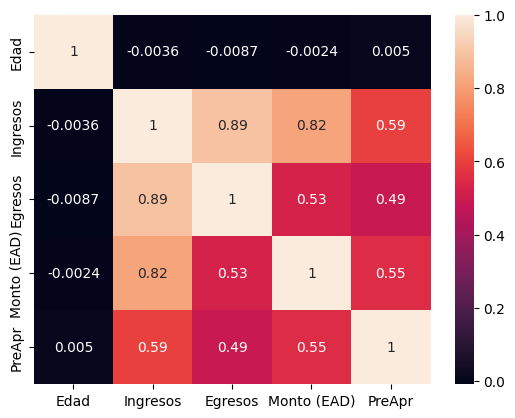

In [ ]:
nxl='/content/sample_data/1. SolicitantesCrédito(USD)- Métodos de Clusterización K-Mean.xlsx'
XDB=pd.read_excel(nxl,sheet_name=1) #base AAA
XD=XDB.iloc[:,[1,10,11,25]] #Datos de entrada
yd=XDB.iloc[:,32]
# Determinamos la correlacion entre las variables
XDB2=XDB.iloc[:,[1,10,11,25,32]]
sns.heatmap(XDB2.corr(), annot=True)


In [ ]:
#analisis de resultados
# SE PUEDE OBSERVAR que las variables que tienen una mayor correlacion entre ellas son las variables de ingresos y egresos con 89%, esto indica que si una variable aumenta su valor, la otra tambien se incrementa( si gana mucho, gasta mucho)


otra correlacion de relevancia es la correlacion entre ingrsos y monto (0.82), personas con altos ingresos, piden montos mayores (bajos ingresos-montos menores)
Se destaca igualmente que la variable que tiene una mayor correlacion con la Var PreApro (salida) es la variable ingresos (0.59)


In [ ]:
np.random.seed(42) # esto permite generar la misma semilla para todos o numeros aleatorios
NC=5 #segmentos o perfiles de clientes
mkm=KMeans(n_clusters=NC, random_state=42)
mkm.fit(XD,yd) #el modelo busca la mejor relacion entre las entrada y la salida

#Obtenemos las caracteristicas de cada grupo
#Representa los perfiles de als personas mkm que encontro el modelo
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD.columns)
display(Tabla)

,Edad,Ingresos,Egresos,Monto (EAD)
0,41.062353,242.798352,213.255141,175.381339
1,40.814394,1943.037897,2034.368232,1151.374380
2,40.842975,1378.277280,825.976626,1500.438821
3,40.995816,1173.957912,1239.367737,656.163350
4,41.129177,711.127537,601.939361,537.170724


para saber los porcentajes de PreApr o PreNeg por segmento, sucursal, o perfil

In [ ]:
#Numero de datos por Cluster
ydp=mkm.labels_ # esto me indica en que cluster queda clasificado cada dato
NDc=np.bincount(ydp) #Numero de datos por segmento
print("El numero de datos por cluster es:",NDc)

El numero de datos por cluster es: [2127  264  485  960 2006]


*Analisis de resultado*

Segun el analisis de este cluster 1 y el cluster 2 son os que poseen los ingresos mas altos 1943 y 1378 respectivamente, clusters qye igualmente son lo que tienen la menor cantidad de solicitantes de credito son 264 y 485. Se destaca el primer cluster, el cual agrupa a las personas con menos ingresos (242), pero es el grupo que posee la mayor cantidad de solicitantes de credito (2127)


3. porcentaje de Preaprobacion

In [ ]:
XDB2['Cluster']=ydp
display(XDB2)

/tmp/ipython-input-159/1392093278.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XDB2['Cluster']=ydp


,Edad,Ingresos,Egresos,Monto (EAD),PreApr,Cluster
0,38,1356.14400,1685.622667,625.562230,1,3
1,51,286.01600,364.462000,140.031984,1,0
2,37,517.46325,629.208889,284.564492,0,4
3,29,473.27000,551.616889,309.647588,1,4
4,42,750.09175,806.715778,500.663578,1,4
...,...,...,...,...,...,...
5837,48,1207.84800,753.801111,748.041791,1,3
5838,31,1472.77200,953.812889,870.793819,1,3
5839,38,773.01975,672.910667,594.947894,1,4
5840,43,635.50175,780.691556,305.580539,1,4


Probabilidad de que a alguien se le Prueba o no dentro de un cluster

In [ ]:
#Determinar el Numero de PreAprobados y PreNegados por cluster
NApr=XDB2.groupby('Cluster').agg({'PreApr':lambda x: (x==1).sum()})
NPrn=XDB2.groupby('Cluster').agg({'PreApr':lambda x: (x==0).sum()})
df2=pd.DataFrame(np.column_stack((NApr,NPrn)),columns=['PreAprobados','PreNegados'])
display(df2)


,PreAprobados,PreNegados
0,292,1835
1,254,10
2,472,13
3,742,218
4,1123,883


Aquí tienes los porcentajes de preaprobación y pre-negación por cluster, donde la suma de ambos porcentajes para cada cluster es 100%:

In [ ]:
# Calcular el total de solicitantes por cluster
total_solicitantes_cluster = df2['PreAprobados'] + df2['PreNegados']

# Calcular los porcentajes
porcentaje_preaprobados = (df2['PreAprobados'] / total_solicitantes_cluster)
porcentaje_prenegados = (df2['PreNegados'] / total_solicitantes_cluster)

# Crear un DataFrame con los porcentajes
df_final_porcentajes = pd.DataFrame({
    'PreAprobados (%)': porcentaje_preaprobados,
    'PreNegados (%)': porcentaje_prenegados
})

# Formatear a porcentaje y mostrar
display(df_final_porcentajes.style.format('{:.2%}'))

,PreAprobados (%),PreNegados (%)
0,13.73%,86.27%
1,96.21%,3.79%
2,97.32%,2.68%
3,77.29%,22.71%
4,55.98%,44.02%


## Resumen Detallado del Análisis K-Means para Preaprobación de Crédito

El Clustering K-Means ha segmentado a los solicitantes de crédito en 5 grupos, revelando perfiles de riesgo y oportunidades estratégicas clave para la FINTECH:

*   **Clusters de Alto Potencial (Clusters 1 y 2 - 96.21% y 97.32% Preaprobación):**
    *   **Perfil:** Clientes con muy alta probabilidad de aprobación, probablemente con historiales financieros sólidos (ingresos altos, egresos gestionados). Cluster 1 tiene los ingresos más altos, Cluster 2 ingresos y montos solicitados muy altos.
    *   **Estrategia:** Priorizar procesos ágiles, ofrecer condiciones de crédito preferenciales (tasas bajas, montos altos) y explorar activamente la fidelización y venta cruzada. Son el núcleo de clientes rentables.

*   **Clusters de Riesgo Moderado (Clusters 3 y 4 - 77.29% y 55.98% Preaprobación):**
    *   **Perfil:** Grupos mixtos que requieren evaluación adicional. El Cluster 3 tiene un buen balance entre aprobación y negación. El Cluster 4 es el más grande pero con una tasa de preaprobación ligeramente superior al 50%, sugiriendo una mezcla de perfiles.
    *   **Estrategia:** Implementar análisis de solvencia más profundos, ofrecer productos con condiciones ajustadas al riesgo (tasas moderadas, plazos específicos) y brindar asesoramiento para mejorar su perfil crediticio y aumentar la preaprobación futura.

*   **Cluster de Alto Riesgo (Cluster 0 - 13.73% Preaprobación):**
    *   **Perfil:** Clientes con muy baja probabilidad de aprobación, generalmente asociados a ingresos y montos solicitados más bajos. Es el cluster con mayor número de solicitantes, lo que significa un gran volumen de posibles denegaciones.
    *   **Estrategia:** La mayoría de las solicitudes serán denegadas o aprobadas bajo condiciones extremadamente restrictivas. Es crucial ofrecer alternativas no crediticias y programas de educación financiera para ayudar a estos solicitantes a mejorar su situación a largo plazo, transformándolos en clientes potenciales futuros.

**Conclusión:** La segmentación K-Means permite una **toma de decisiones granular y optimizada**. La FINTECH puede maximizar aprobaciones rentables en grupos de bajo riesgo, gestionar el riesgo eficientemente en grupos moderados y minimizar pérdidas en segmentos de alto riesgo, lo que se traduce en una mayor eficiencia operativa y una mejor gestión de cartera.

4. que pasa  si aparece una nueva persona y esta va a tener las siguientes variables?
Edad 30
Ingresos 500
Egresos 200
Monto 150


Para clasificar a una nueva persona con las variables proporcionadas, primero debemos formatear sus datos de la misma manera que los datos de entrenamiento y luego usar el modelo `mkm` para predecir a qué cluster pertenece.

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
# Datos de la nueva persona
nueva_persona = pd.DataFrame({
    'Edad': [30],
    'Ingresos': [500],
    'Egresos': [200],
    'Monto (EAD)': [150]
})

# Predecir el cluster para la nueva persona
cluster_nueva_persona = mkm.predict(nueva_persona)

print(f"La nueva persona pertenece al Cluster: {cluster_nueva_persona[0]}")

# Obtener los porcentajes de preaprobación para ese cluster
cluster_id = cluster_nueva_persona[0]
porcentaje_aprobacion = df_final_porcentajes.loc[cluster_id, 'PreAprobados (%)']
porcentaje_negacion = df_final_porcentajes.loc[cluster_id, 'PreNegados (%)']

print(f"Según el análisis, este cluster tiene un {porcentaje_aprobacion:.2%} de preaprobación y un {porcentaje_negacion:.2%} de pre-negación.")

print("\nAnálisis de la nueva persona:")
if porcentaje_aprobacion >= 0.70:
    print(f"Dado que la nueva persona cae en el Cluster {cluster_id} con una alta probabilidad de preaprobación, se considera un solicitante de alto potencial.")
elif porcentaje_aprobacion >= 0.40:
    print(f"Dado que la nueva persona cae en el Cluster {cluster_id} con una probabilidad de preaprobación moderada, se recomienda una evaluación más profunda.")
else:
    print(f"Dado que la nueva persona cae en el Cluster {cluster_id} con una baja probabilidad de preaprobación, se considera un solicitante de alto riesgo.")



La nueva persona pertenece al Cluster: 0
Según el análisis, este cluster tiene un 13.73% de preaprobación y un 86.27% de pre-negación.

Análisis de la nueva persona:
Dado que la nueva persona cae en el Cluster 0 con una baja probabilidad de preaprobación, se considera un solicitante de alto riesgo.


A continuación, se visualizan los resultados del clustering K-Means para los solicitantes de crédito, mostrando la distribución de los clusters en función de la `Edad` y los `Ingresos`.

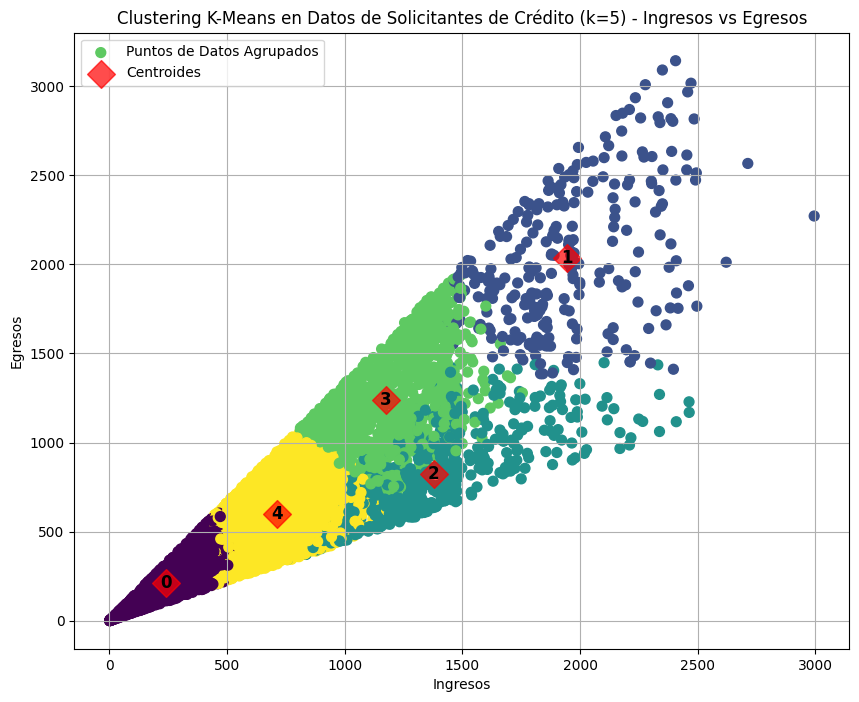

In [ ]:
# Re-calcular ydp para el conjunto completo de datos XD, ya que pudo haber sido sobreescrito
ydp = mkm.predict(XD)

# Obtener las coordenadas de los centroides de los clusters
Centers = mkm.cluster_centers_ # Ya definida en esta celda

# Visualizar los resultados del clustering del caso de estudio
plt.figure(figsize=(10, 8))
plt.scatter(XD.iloc[:, 1], XD.iloc[:, 2], c=ydp, s=50, cmap='viridis', label='Puntos de Datos Agrupados')
plt.scatter(Centers[:, 1], Centers[:, 2], c='red', s=200, alpha=0.7, marker='D', label='Centroides')

# Agregar números a cada centroide
for i, center in enumerate(Centers):
    plt.text(center[1], center[2], str(i), fontsize=12, color='black', ha='center', va='center', weight='bold')

plt.title('Clustering K-Means en Datos de Solicitantes de Crédito (k=5) - Ingresos vs Egresos')
plt.xlabel(XD.columns[1]) # 'Ingresos'
plt.ylabel(XD.columns[2]) # 'Egresos'
plt.legend()
plt.grid(True)
plt.show()

Edad= cluster 0
Ingresos = 1
Egresos = 2
Monto= 3

## Análisis de la Gráfica de Clustering K-Means (Ingresos vs Egresos)

Esta visualización es crucial para entender la segmentación de solicitantes de crédito desde una perspectiva de capacidad financiera. La gráfica de dispersión de Ingresos vs Egresos nos permite extraer las siguientes conclusiones clave:

*   **Identificación de Perfiles de Riesgo:**
    *   **Segmentos de Bajo Riesgo (Ingresos Altos, Egresos Moderados/Altos):** Ubicados en la parte superior derecha del gráfico, estos clusters representan a solicitantes con una capacidad económica robusta. Aunque pueden tener egresos altos, sus ingresos compensan, indicando mayor solvencia. Son los candidatos más atractivos para la preaprobación de crédito.
    *   **Segmentos de Alto Riesgo (Ingresos Bajos, Egresos Bajos/Moderados):** Concentrados en la parte inferior izquierda, estos clusters (como el Cluster 0) agrupan a solicitantes con una capacidad de generación de ingresos limitada. Independientemente de si sus egresos son bajos, su ingreso total les confiere un riesgo más elevado para la concesión de crédito.
    *   **Segmentos con Potencial (Ingresos Moderados, Egresos Moderados):** Los clusters situados en la zona central pueden representar a solicitantes con un equilibrio entre ingresos y egresos, donde una evaluación más detallada podría determinar su viabilidad crediticia.

*   **Correlación entre Ingresos y Egresos:** La gráfica refuerza la fuerte correlación positiva entre ingresos y egresos observada previamente. Los clusters tienden a alinearse a lo largo de una diagonal, lo que significa que a mayores ingresos, generalmente mayores egresos (y viceversa). Sin embargo, el K-Means es capaz de discernir matices dentro de esta correlación, creando segmentos que van más allá de una simple relación lineal.

*   **Decisiones Estratégicas:** La FINTECH puede utilizar esta visualización para:
    *   **Refinar Ofertas:** Adaptar productos crediticios (montos, tasas, plazos) a la capacidad real de pago de cada segmento.
    *   **Gestión del Riesgo:** Implementar filtros más estrictos o requerir garantías adicionales para los segmentos de alto riesgo, y agilizar procesos para los de bajo riesgo.
    *   **Detección de Clientes Objetivo:** Identificar fácilmente a los segmentos de clientes más deseables o a aquellos que necesitan apoyo para mejorar su situación financiera.

En conclusión, esta representación visual es una herramienta poderosa para validar y comprender los perfiles de los clusters, facilitando a la FINTECH una toma de decisiones más intuitiva y estratégica en el proceso de preaprobación de crédito.